In [204]:
using Plots, CSV, DataFrames, LinearAlgebra, Distributions
fdd(x) = @. 1/(exp(x) + 1)


fdd (generic function with 2 methods)

Fermi-Dairc Distribution
$$p(\epsilon) = \frac{1}{1+e^{\beta (\epsilon - \mu)}}$$

Linear function
$$\epsilon(\vec{\theta},\vec{x}) = \vec{\theta}\cdot\vec{x} = x_i\theta^i$$

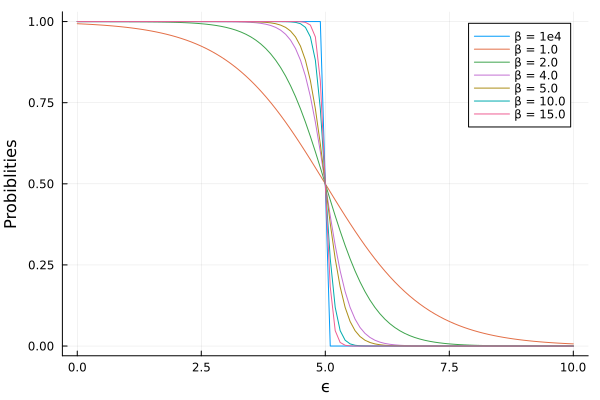

In [205]:
ϵ = 0:0.1:10
μ = 5.
βs = [1., 2., 4., 5., 10., 15.]

p = plot(
    ϵ,fdd(ϵ,1e4,μ),
    label = "β = 1e4",
    xlabel = "ϵ",
    ylabel = "Probiblities",
    )

for β in βs
    plot!(
    ϵ,fdd(ϵ,β,μ),
    label = "β = $β",
    xlabel = "ϵ",
    ylabel = "Probiblities",
    )
end 
display(p)

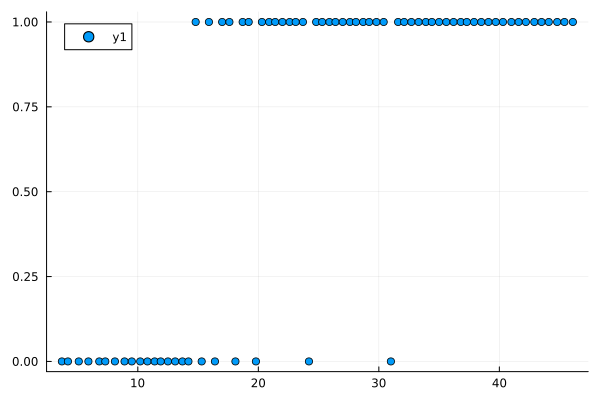

(72, 3)
["num", "diameter_mm", "malignant"]


In [220]:
data = CSV.read("data.csv",DataFrame);
insertcols!(data, 1 ,  :num =>ones(nrow(data)))
size(data) |> println
names(data) |> println
features = data[:,1:2]
labels    = data[:,3]; 
p = scatter(features[:,2],labels)
display(p)

$$\epsilon(\vec{\theta},\vec{x}) = \vec{\theta}\cdot\vec{x} = x_i\theta^i$$
$$\vec{x} = 1\vec{e}_1 + x\vec{e}_2$$
$$\epsilon(\vec{\theta},\vec{x}) = \theta_1 + x \theta_2$$
- the linear function


In [207]:
function Entropy(features, labels, θ)

    scores = Matrix(features) * θ
    p = fdd.(scores) 
    
  
    sample_loss = (1 .- labels) .* log.(1 .+ p) + labels .* log.(2 .- p)
    
   
    return mean(sample_loss, dims=1)  
end

Entropy (generic function with 1 method)

MC

In [208]:
n = 100
tm = 1e4
tmi = -1e4
ths = [rand(Uniform(tmi,tm), n) rand(Uniform(tmi,tm), n)]'
es  = Entropy(features,labels,ths)
min_val, min_idx = findmin(es)
println("最小损失: $min_val, 对应的参数组索引: $min_idx")

最小损失: 0.05776226504671679, 对应的参数组索引: CartesianIndex(1, 55)


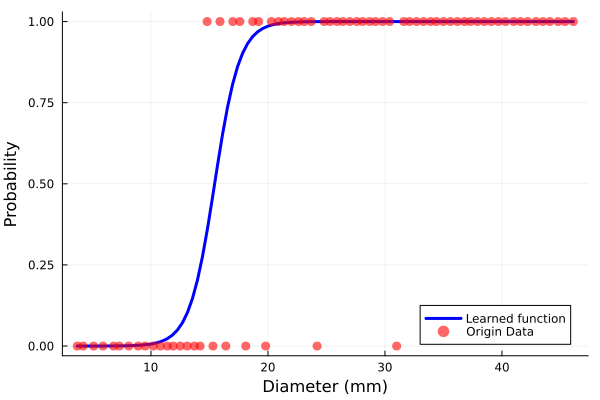

In [219]:
β = 5e-3
best_thes , min_loss = ths[:,min_idx[2]] , es[min_idx[2]]
x = range(minimum(features[:, 2]), maximum(features[:, 2]), length=100)
p = plot(x, fdd.(β .* (best_thes[1] .+ best_thes[2] .* x)), 
    label="Learned function", 
    linewidth=3, 
    color=:blue,
    xlabel="Diameter (mm)",
    ylabel="Probability",
    legend=:bottomright)

scatter!(features[:,2], labels, 
    label="Origin Data", 
    color=:red, 
    markershape=:circle, 
    markerstrokewidth=0, 
    alpha=0.6,
    markersize=5)